In [1]:
import sys
sys.path.append("/global/u1/r/rmastand/mlpf-ssl/particlemind")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import awkward as ak



In [3]:
path_to_original_calo = "/pscratch/sd/r/rmastand/particlemind/data/p8_ee_tt_ecm365_parquetfiles/reco_p8_ee_tt_ecm365_60000.parquet"
path_to_original_tokens = "/pscratch/sd/r/rmastand/particlemind/tokens/p8_ee_tt_ecm365_parquetfiles/reco_p8_ee_tt_ecm365_60210.parquet"

path_to_generated_calo = ""
path_to_generated_tokens = ""


path_to_embedder_checkpoint = "/pscratch/sd/r/rmastand/particlemind/vqvae_training/best_models/embedder_test_val_loss_epoch=48.ckpt"



In [4]:
# load in data

original_calo = ak.from_parquet(path_to_original_calo)["calo_hit_features"]
original_tokens = ak.from_parquet(path_to_original_tokens)

#generated_calo = ak.from_parquet(path_to_generated_calo)
#generated_tokens = ak.from_parquet(path_to_generated_tokens)

In [5]:
# load in embedder. TODO: RECONSTRUCTION W/O generation
test_embedder = True

if test_embedder:
    
    from src.datasets.CLDHits import CLDHitsSingleFile, inverse_standardize_calo_hit_features
    from src.models.vqvae import VQVAELightning
    from src.datasets.utils import Collater
    from torch.utils.data import DataLoader
    
    
    embedder = VQVAELightning.load_from_checkpoint(
               path_to_embedder_checkpoint,
            )
    
    
    file_dataset = CLDHitsSingleFile(path_to_original_calo, by_event=True)

    file_loader = DataLoader(
        file_dataset,
        batch_size=2,
        collate_fn=Collater(empty_key="calo_hit_features", variable_size_keys="all"),
        num_workers=1,
        shuffle=False
    )
    

    reco_x, reco_y, reco_z, reco_e = ak.Array([]), ak.Array([]) , ak.Array([]) ,  ak.Array([]) 
    for i, x_batch in enumerate(file_loader):

        print(i)
    
        if i > 10:
            break
    
        # move to device
        features_batch = x_batch["calo_hit_features"].to(embedder.device)
        mask_batch = x_batch["mask"].to(embedder.device)
        x_particle_reco, _ = embedder.forward(features_batch, mask_batch)

        for row in range(x_particle_reco.shape[0]):

            event = x_particle_reco[row].detach().cpu().numpy()
            mask = mask_batch[row].int().detach().cpu().numpy()

            event = inverse_standardize_calo_hit_features(event)

            reco_x = ak.concatenate([reco_x, ak.Array([event[:,0][mask==1]])], axis = 0)
            reco_y = ak.concatenate([reco_y, ak.Array([event[:,1][mask==1]])], axis = 0)
            reco_z = ak.concatenate([reco_z, ak.Array([event[:,2][mask==1]])], axis = 0)
            reco_e = ak.concatenate([reco_e, ak.Array([event[:,3][mask==1]])], axis = 0)



/pscratch/sd/r/rmastand/particlemind_env/lib/python3.8/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/pscratch/sd/r/rmastand/particle

0
(9837, 4)
[1 1 1 ... 1 1 1]
(9837,)
9837
9837
(9837, 4)
[1 1 1 ... 0 0 0]
(9837,)
9282
9282
1
(10320, 4)
[1 1 1 ... 0 0 0]
(10320,)
7510
7510
(10320, 4)
[1 1 1 ... 1 1 1]
(10320,)
10320
10320
2
(9634, 4)
[1 1 1 ... 1 1 1]
(9634,)
9634
9634
(9634, 4)
[1 1 1 ... 0 0 0]
(9634,)
6509
6509
3
(7711, 4)
[1 1 1 ... 1 1 1]
(7711,)
7711
7711
(7711, 4)
[1 1 1 ... 0 0 0]
(7711,)
6952
6952
4
(5369, 4)
[1 1 1 ... 0 0 0]
(5369,)
4406
4406
(5369, 4)
[1 1 1 ... 1 1 1]
(5369,)
5369
5369
5
(11748, 4)
[1 1 1 ... 1 1 1]
(11748,)
11748
11748
(11748, 4)
[1 1 1 ... 0 0 0]
(11748,)
7990
7990
6
(9850, 4)
[1 1 1 ... 0 0 0]
(9850,)
8574
8574
(9850, 4)
[1 1 1 ... 1 1 1]
(9850,)
9850
9850
7
(8361, 4)
[1 1 1 ... 0 0 0]
(8361,)
5617
5617
(8361, 4)
[1 1 1 ... 1 1 1]
(8361,)
8361
8361
8
(8833, 4)
[1 1 1 ... 1 1 1]
(8833,)
8833
8833
(8833, 4)
[1 1 1 ... 0 0 0]
(8833,)
6444
6444
9
(10466, 4)
[1 1 1 ... 0 0 0]
(10466,)
9208
9208
(10466, 4)
[1 1 1 ... 1 1 1]
(10466,)
10466
10466
10
(10710, 4)
[1 1 1 ... 1 1 1]
(10710,)
1

In [6]:
# compare tokens

print(original_tokens)

[[484, 53, 343, 380, 72, 484, 484, ..., 411, 411, 391, 495, 343, 107, 450], ...]


# Plot multiple events


In [7]:
position_lim = 5000
e_lim = 10

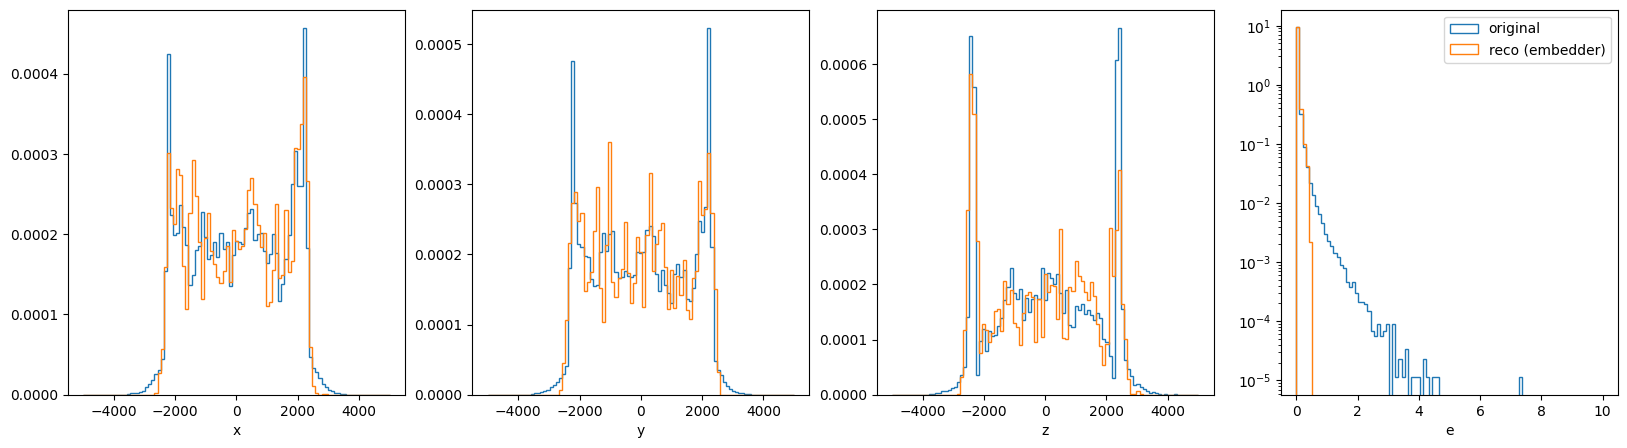

In [8]:
# calo

nbins = 100

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

ax[0].hist(ak.flatten(original_calo["position.x"]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
if test_embedder:
    ax[0].hist(ak.flatten(reco_x), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[0].set_xlabel("x")

ax[1].hist(ak.flatten(original_calo["position.y"]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
if test_embedder:
    ax[1].hist(ak.flatten(reco_y), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[1].set_xlabel("y")

ax[2].hist(ak.flatten(original_calo["position.z"]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
if test_embedder:
    ax[2].hist(ak.flatten(reco_z), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[2].set_xlabel("z")

ax[3].hist(ak.flatten(original_calo["energy"]), bins = np.linspace(0, e_lim, nbins), histtype = "step", label = "original", density=True)
if test_embedder:
    ax[3].hist(ak.flatten(reco_e), bins = np.linspace(0, e_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[3].set_xlabel("e")
ax[3].set_yscale("log")
ax[3].legend()

plt.show()

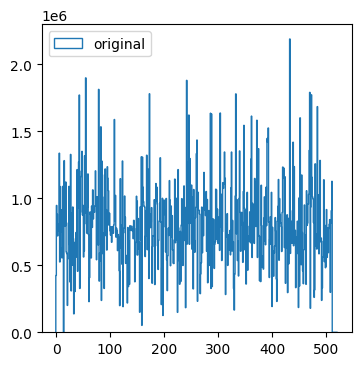

In [9]:
# tokens

fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist(ak.flatten(original_tokens), bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original")
ax.legend()
plt.show()

# Plot single events

9837 9837


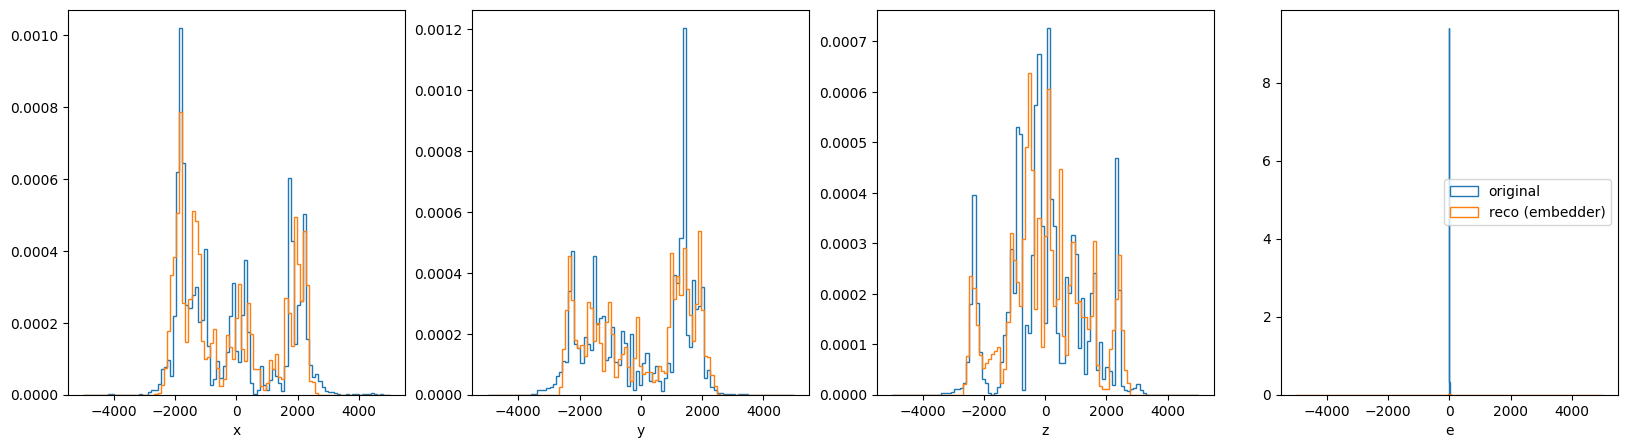

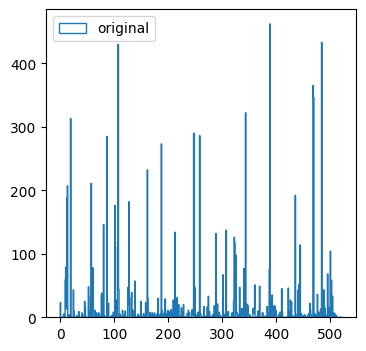

9282 9282


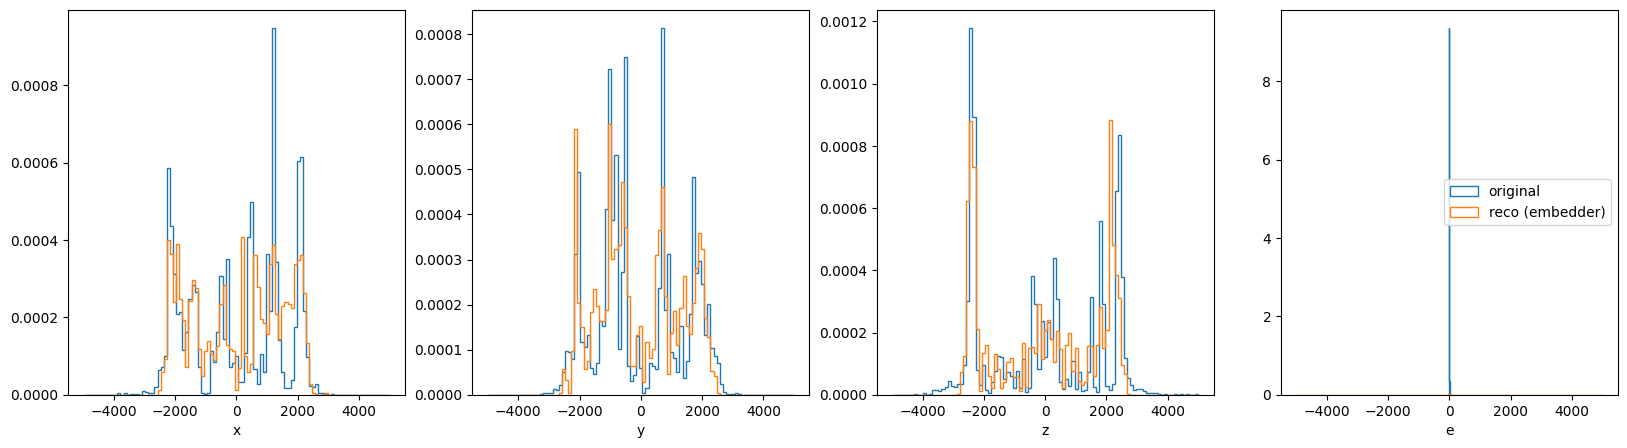

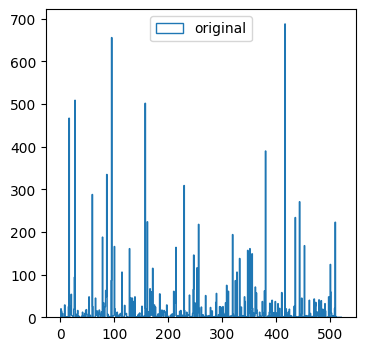

7510 7510


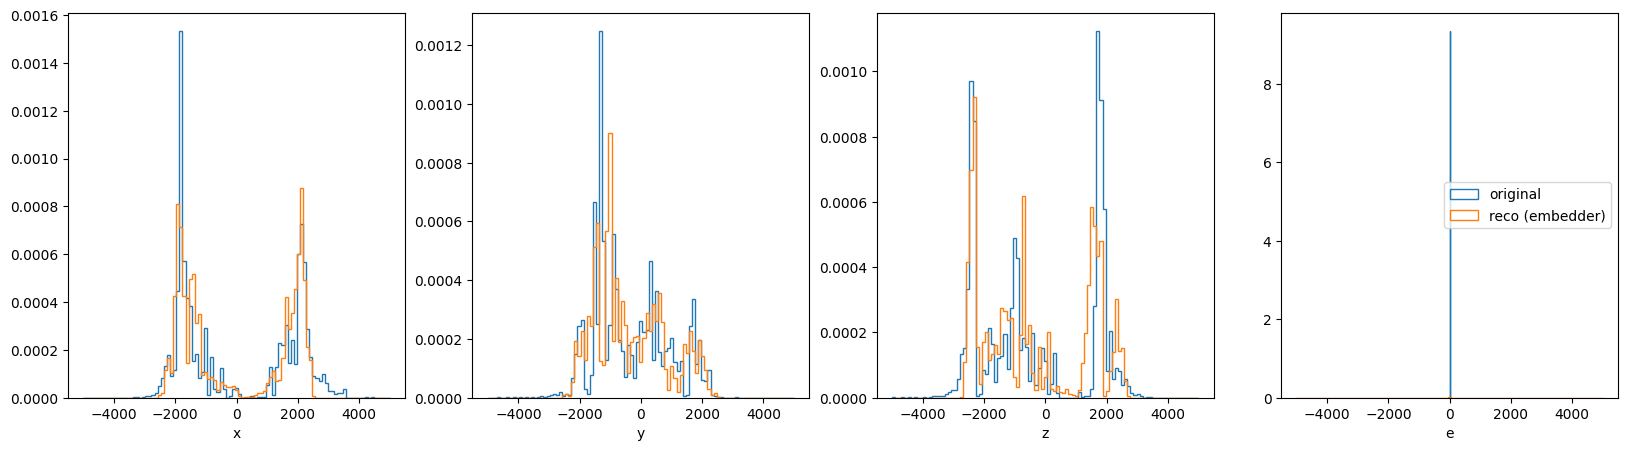

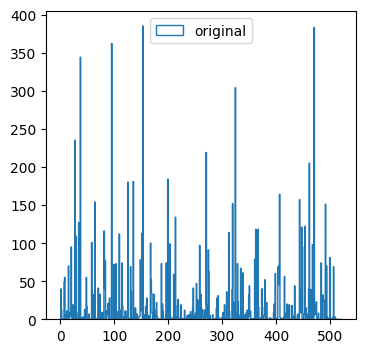

10320 10320


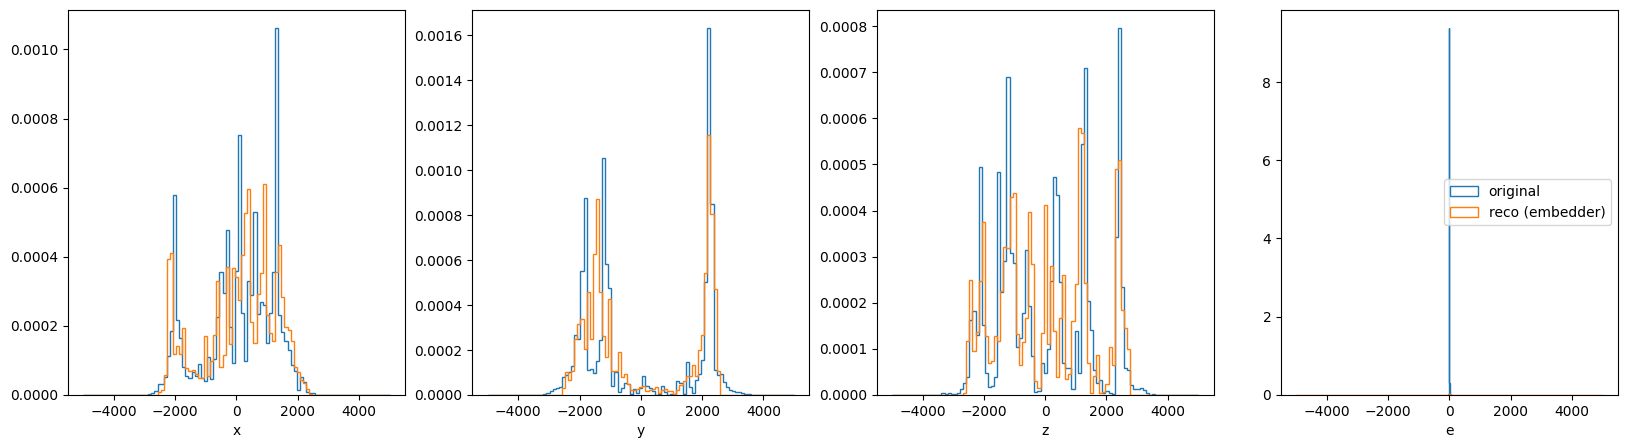

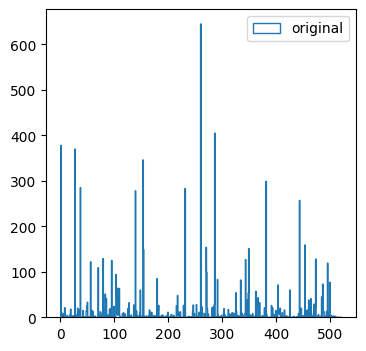

9634 9634


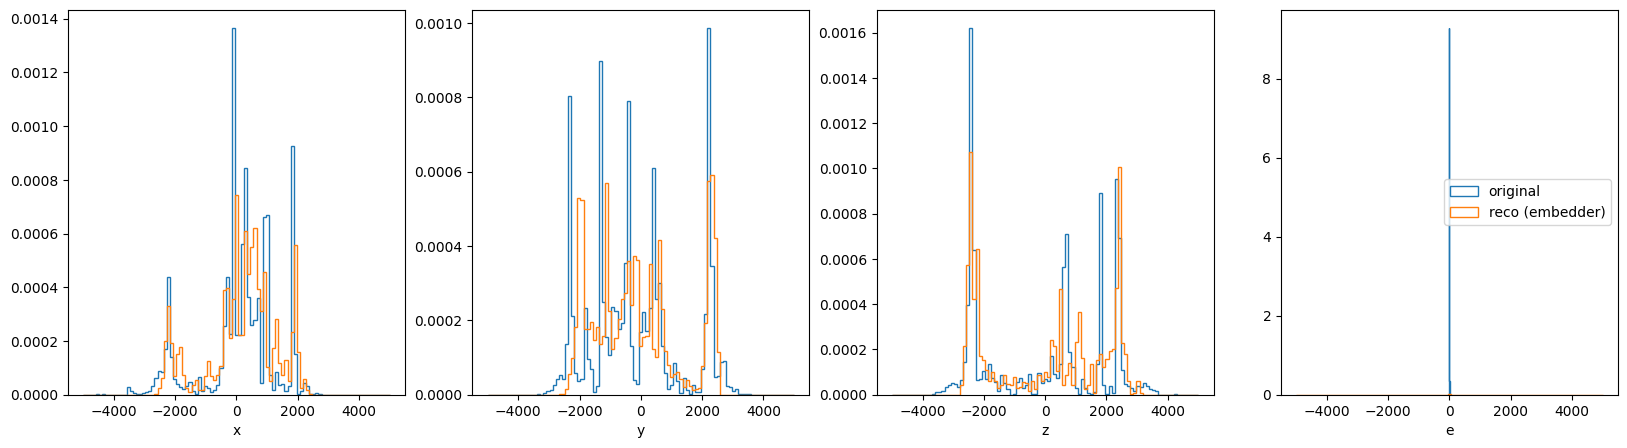

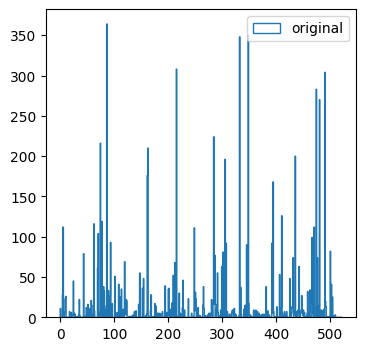

6509 6509


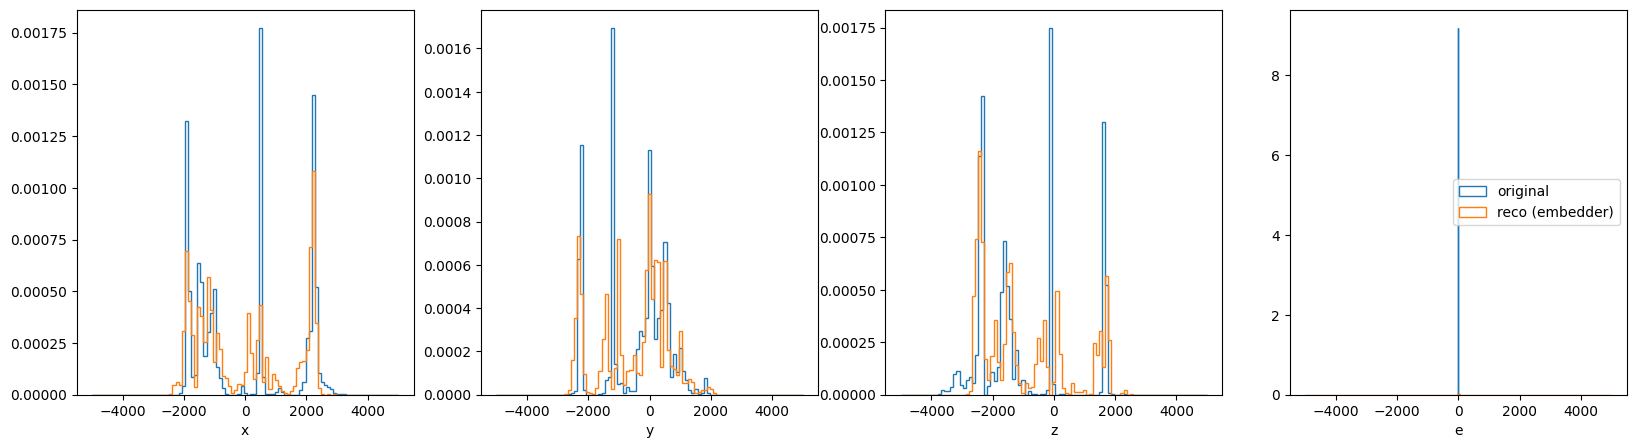

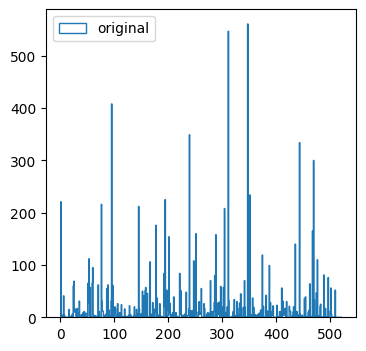

7711 7711


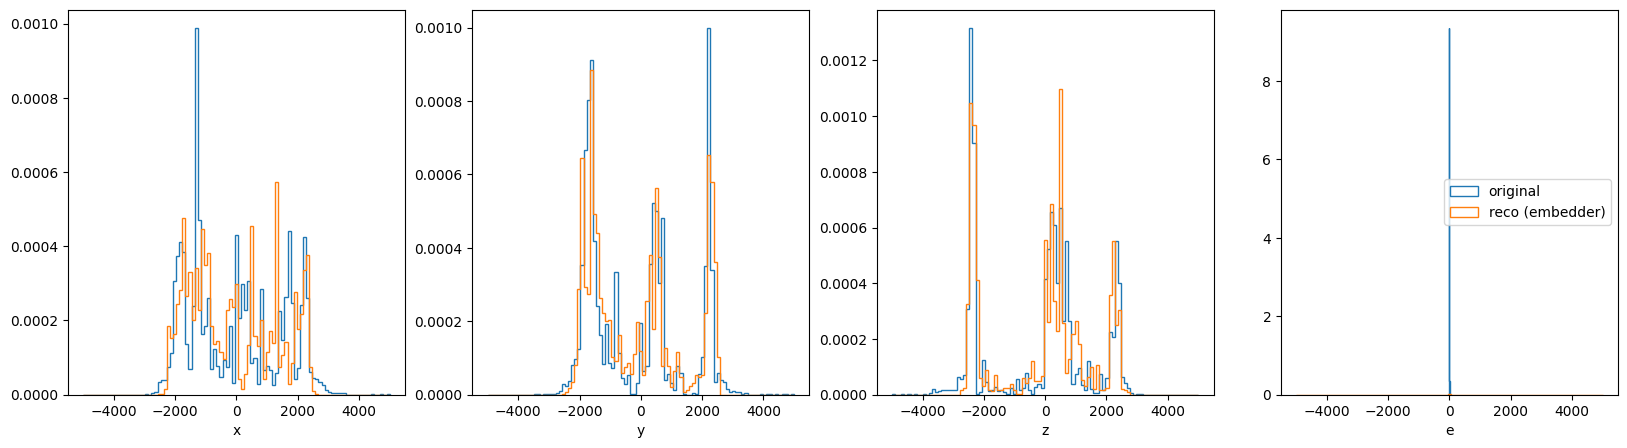

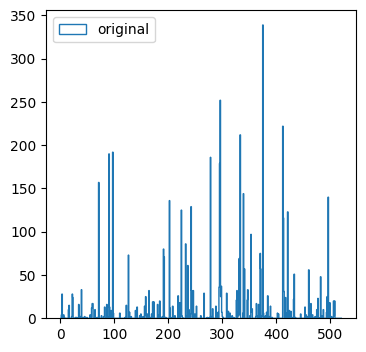

6952 6952


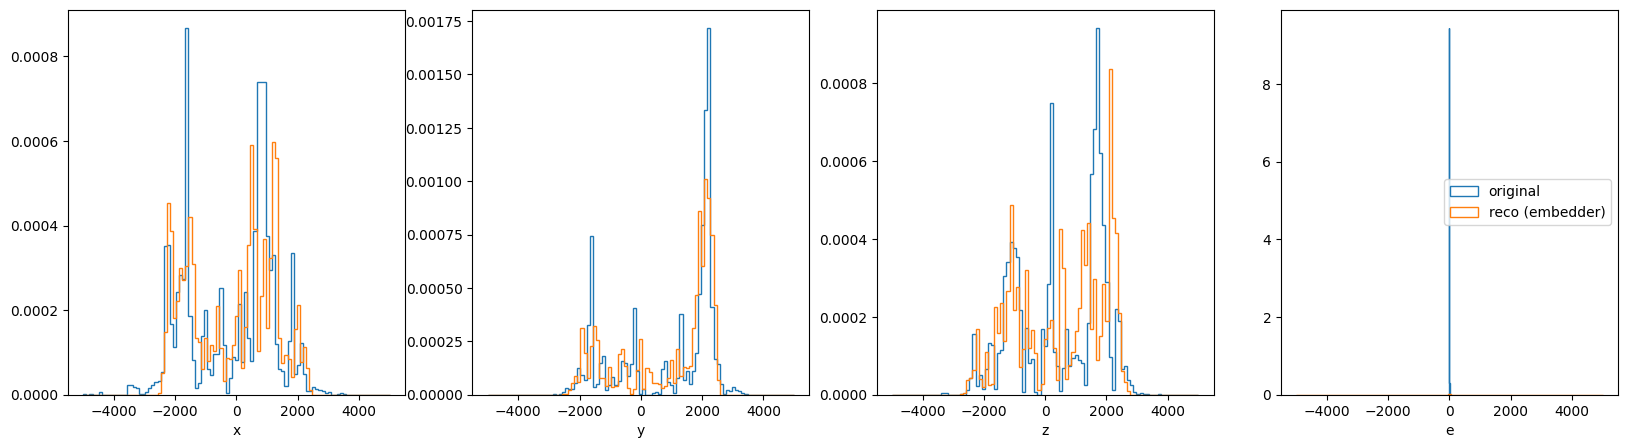

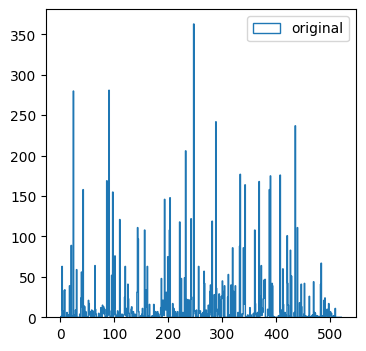

4406 4406


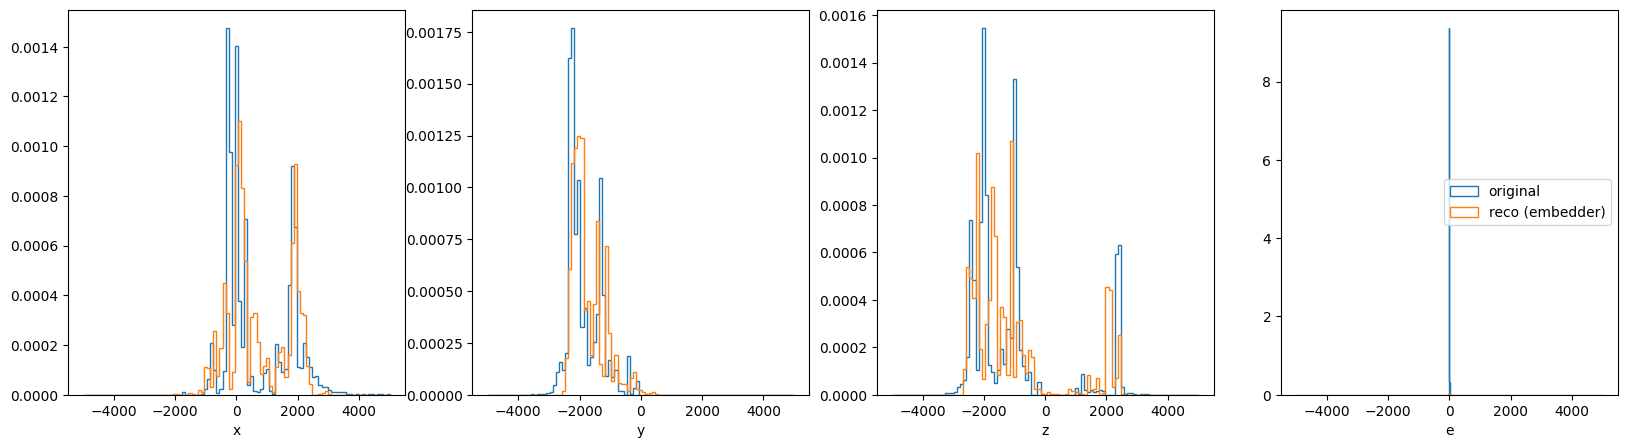

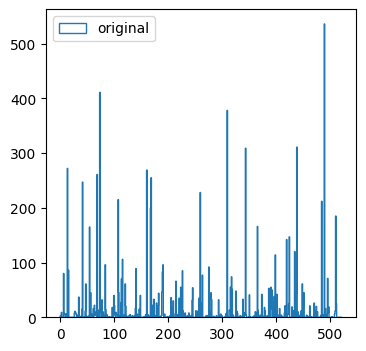

5369 5369


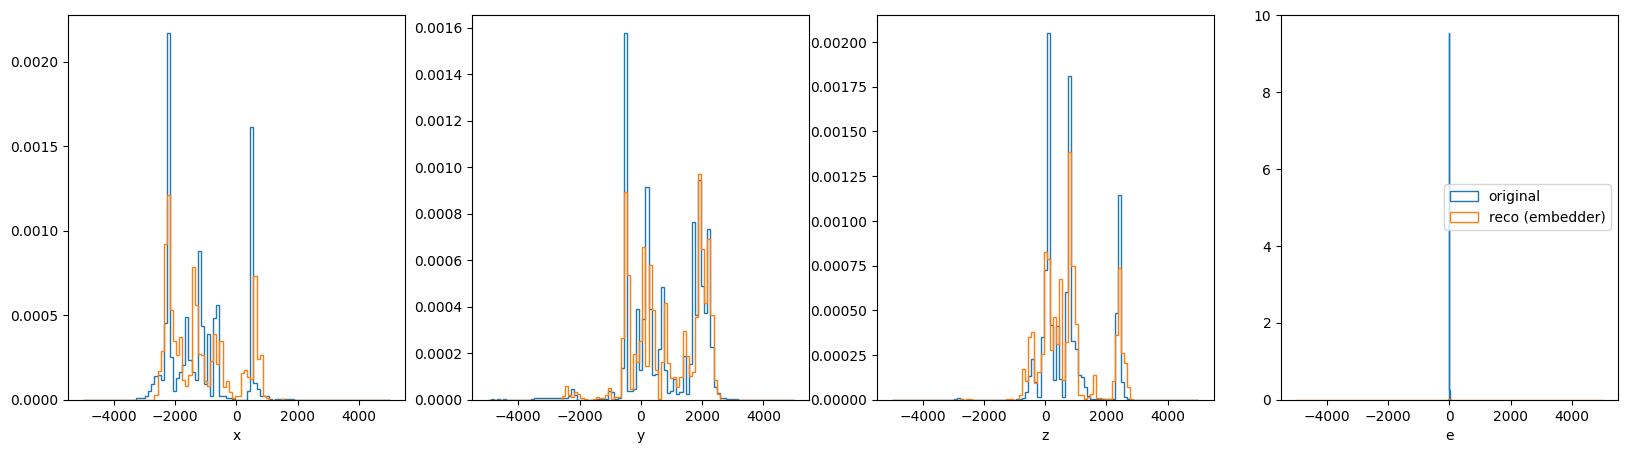

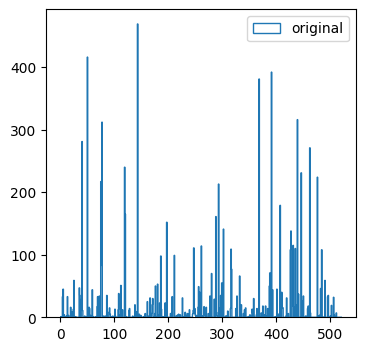

In [10]:
nbins = 100


for i in range(10):

    fig, ax = plt.subplots(1, 4, figsize = (20, 5))
    
    ax[0].hist(original_calo["position.x"][i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    if test_embedder:
        ax[0].hist(reco_x[i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[0].set_xlabel("x")
    
    ax[1].hist(original_calo["position.y"][i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    if test_embedder:
        ax[1].hist(reco_y[i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[1].set_xlabel("y")
    
    ax[2].hist(original_calo["position.z"][i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    if test_embedder:
        ax[2].hist(reco_z[i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[2].set_xlabel("z")
    
    ax[3].hist(original_calo["energy"][i], bins = np.linspace(0, e_lim, nbins), histtype = "step", label = "original", density=True)
    if test_embedder:
        ax[3].hist(reco_e[i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)
    ax[3].set_xlabel("e")
    ax[3].legend()

    
    plt.show()


    fig, ax = plt.subplots(1, 1, figsize = (4, 4))
    ax.hist(original_tokens[i], bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original")
    ax.legend()
    plt.show()